Feature Importance is based on

how much each feature reduces impurity across all splits in the tree.

The greater the total impurity reduction contributed by a feature, the higher its importance score.

In [37]:
# ==========================
# Data Manipulation
# ==========================
import pandas as pd
import numpy as np

# ==========================
# Data Visualization
# ==========================
from IPython.display import display
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================
# Train-Test Split
# ==========================
from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    cross_val_score
)

# ==========================
# Decision Tree
# ==========================
from sklearn.tree import (
    DecisionTreeClassifier,
    plot_tree
)

# ==========================
# Evaluation Metrics
# ==========================
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score
)

# ==========================
# Save Model
# ==========================
import joblib

from sklearn.model_selection import GridSearchCV

In [2]:
#Load data
data = pd.read_csv(r"C:\Users\Monika Dogra\Desktop\data\diabetes_2.csv")
display(data.head(5))

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [3]:
display(data.shape)
display(data.info())
display(data.describe())

(768, 9)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


None

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [4]:
(data == 0).sum()

Pregnancies                 111
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                     500
dtype: int64

In [5]:
(data["Glucose"] == 0).sum()

5

In [6]:
#missing values:
missing = data.isnull().sum()
display(missing)

missing_percentage = (data.isnull().sum() / len(data)) * 100

missing_percentage = missing_percentage.sort_values(ascending=False)

display(missing_percentage)

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

Pregnancies                 0.0
Glucose                     0.0
BloodPressure               0.0
SkinThickness               0.0
Insulin                     0.0
BMI                         0.0
DiabetesPedigreeFunction    0.0
Age                         0.0
Outcome                     0.0
dtype: float64

In [7]:
display("duplicates")
data.duplicated().sum()

'duplicates'

0

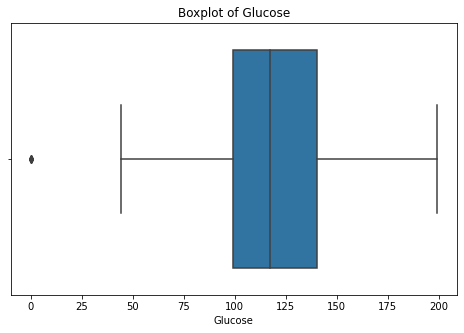

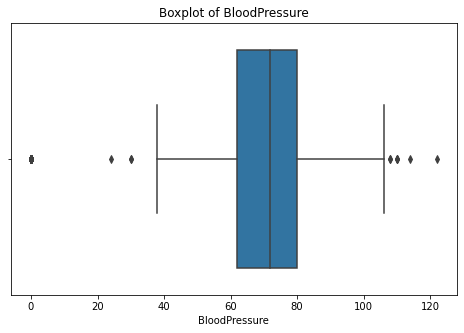

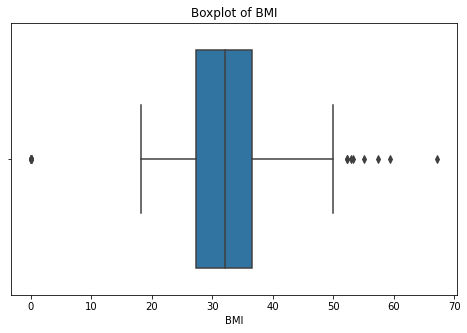

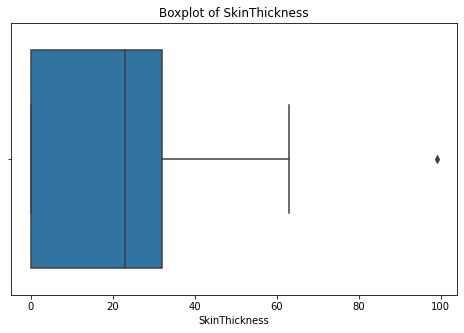

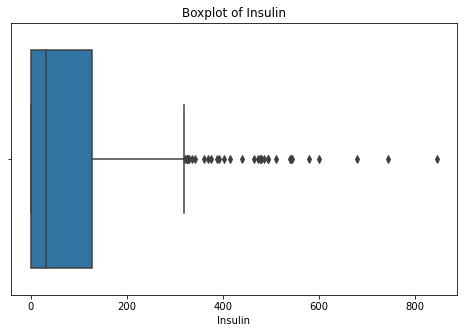

In [8]:
#check outliers
def outlier_check(col):
    plt.figure(figsize=(8,5))
    sns.boxplot(x=data[col])
    plt.title(f"Boxplot of {col}")
    plt.show()
                       
cols = ["Glucose","BloodPressure","BMI","SkinThickness","Insulin"]
for col in range (len(cols)):
    outlier_check(cols[col])

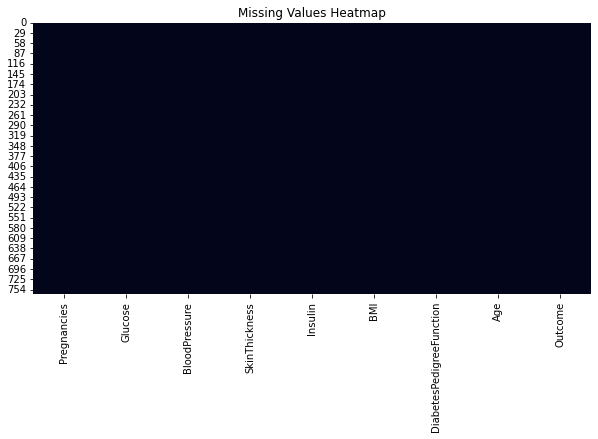

In [9]:
# Visualize Missing Values
plt.figure(figsize=(10,5))

sns.heatmap(data.isnull(), cbar=False)

plt.title("Missing Values Heatmap")

plt.show()

In [10]:
def replace_value(col):
    data[col] =data[col].replace(0, np.nan)
    #Then impute.
    data[col].fillna(
        data[col].median(),
        inplace=True
    )

cols = ["Glucose","BloodPressure","BMI","SkinThickness","Insulin"]
for col in cols:
    replace_value(col)
(data["BloodPressure"] == 0).sum()

# columns_with_invalid_zeros = [
#     "Glucose",
#     "BloodPressure",
#     "SkinThickness",
#     "Insulin",
#     "BMI"
# ]

# df[columns_with_invalid_zeros] = df[columns_with_invalid_zeros].replace(0, np.nan)

0

fillna() is useful for quick data cleaning in pandas, but SimpleImputer is preferred in machine learning pipelines because it learns replacement values from the training data, stores them, and applies the same values consistently to validation, test, and future production data. This helps maintain consistency and reduces the risk of data leakage when used correctly.

In [11]:
(data["Glucose"] == 0).sum()

0

In [12]:
display(data["Outcome"].value_counts())

display(data["Outcome"].value_counts(normalize=True) * 100)

0    500
1    268
Name: Outcome, dtype: int64

0    65.104167
1    34.895833
Name: Outcome, dtype: float64

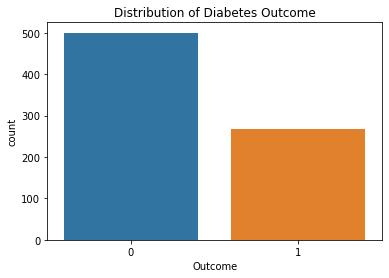

In [13]:
# distribution of target column
sns.countplot(x="Outcome", data=data)

plt.title("Distribution of Diabetes Outcome")
plt.show()


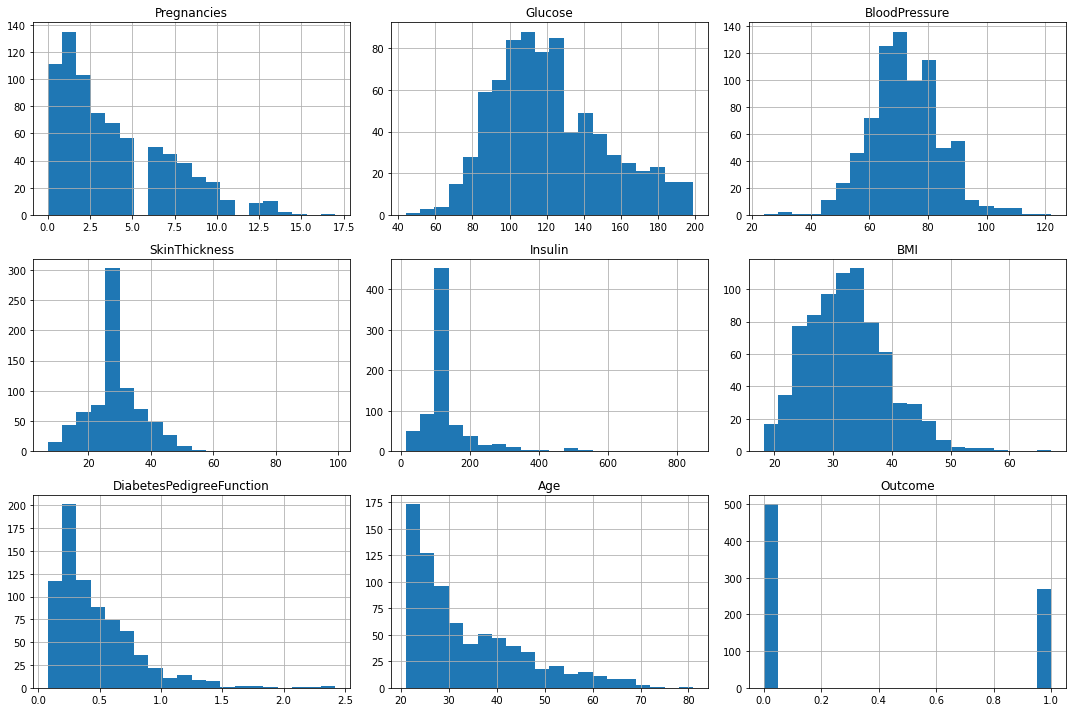

In [14]:
data.hist(figsize=(15,10), bins=20)

plt.tight_layout()

plt.show()

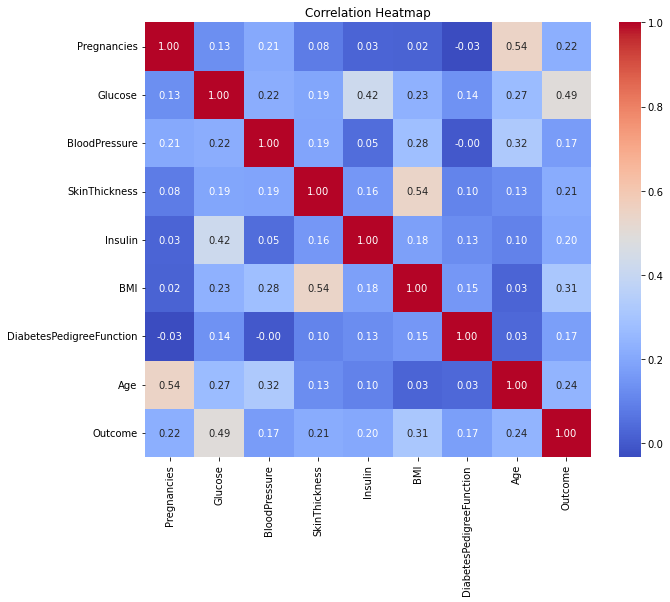

In [15]:
# Correlation Heatmap:
# Correlation measures how strongly two variables move together. Ranges from -1 to +1
plt.figure(figsize=(10,8))

sns.heatmap(
    data.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

# Glucose → Outcome = 0.490

# Meaning: Higher glucose is associated with a higher chance of diabetes.

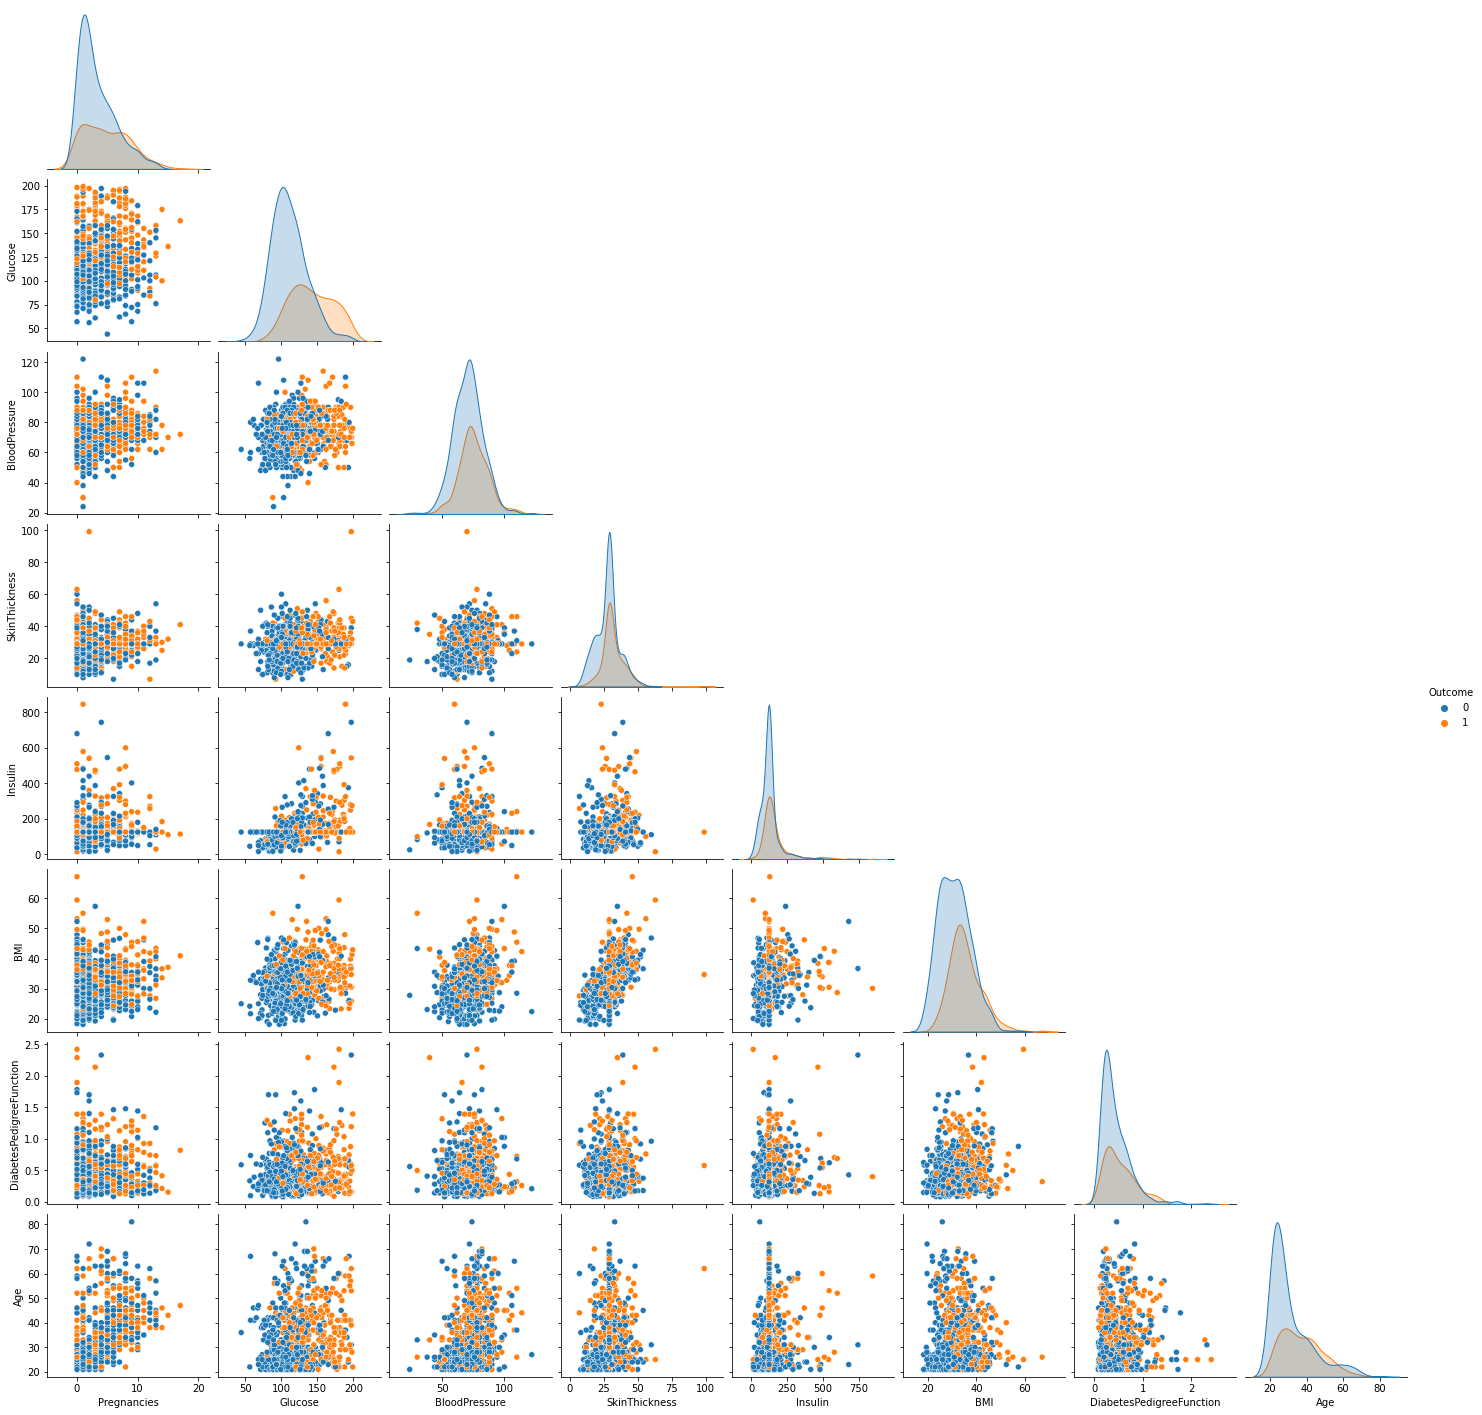

In [16]:
#Pairplot :
sns.pairplot(
    data,
    hue="Outcome",
    corner=True
)

plt.show()

#Interpretation

# If diabetic patients cluster separately in some feature combinations, those features may be highly informative for the model.

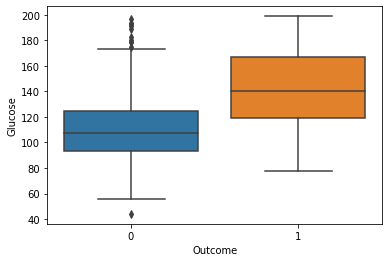

In [17]:
# #Feature vs Outcome :
# If the median glucose level is much higher for Outcome = 1 than for Outcome = 0, 
# it suggests that Glucose is a strong predictor of diabetes.

plt.figure(figsize=(6,4))

sns.boxplot(
    x="Outcome",
    y="Glucose",
    data=data
)

plt.show()

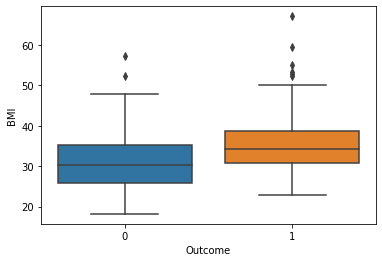

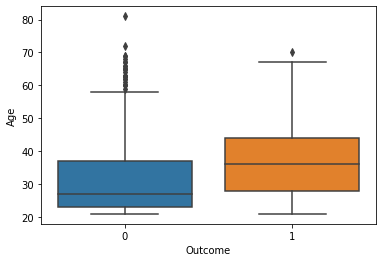

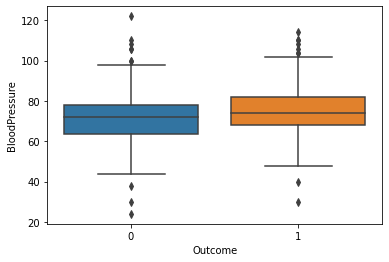

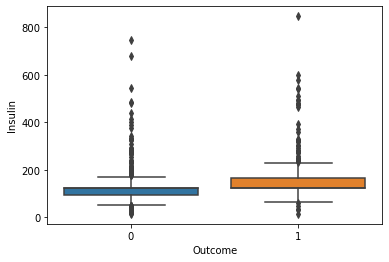

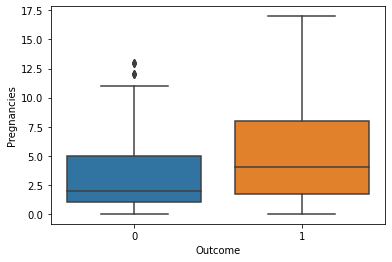

In [18]:
# same analysis for other features:

features = [
    "BMI",
    "Age",
    "BloodPressure",
    "Insulin",
    "Pregnancies"
]

def plot_2(feature):
    plt.figure(figsize=(6,4))

    sns.boxplot(
        x="Outcome",
        y=feature,
        data=data
    )

    plt.show()
for feature in features:
    plot_2(feature)

In [19]:
## Feature Scaling
# ----------------------------
# Decision Trees are not sensitive to feature scaling.
# Therefore, StandardScaler is not applied.

In [20]:
# train test split
X = data.drop("Outcome", axis=1)
y = data["Outcome"]

In [21]:
display(X.head())
display(y.head())

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,6,148.0,72.0,35.0,125.0,33.6,0.627,50
1,1,85.0,66.0,29.0,125.0,26.6,0.351,31
2,8,183.0,64.0,29.0,125.0,23.3,0.672,32
3,1,89.0,66.0,23.0,94.0,28.1,0.167,21
4,0,137.0,40.0,35.0,168.0,43.1,2.288,33


0    1
1    0
2    1
3    0
4    1
Name: Outcome, dtype: int64

In [22]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)
#We train on 80% and test on 20%.
#random_state=42 :This ensures reproducibility.Every run uses a different random split.
# every run produces the same split, making experiments reproducible.

# Important: 42 has no special meaning. It's simply a commonly used constant. 
# Any fixed integer (e.g., 0, 10, 100) would work.

# stratify=y : both training and testing preserve approximately the same class proportions.

In [23]:
print("Training Features:", X_train.shape)
print("Testing Features :", X_test.shape)

print("Training Labels :", y_train.shape)
print("Testing Labels  :", y_test.shape)

Training Features: (614, 8)
Testing Features : (154, 8)
Training Labels : (614,)
Testing Labels  : (154,)


In [28]:
# define the model
model = DecisionTreeClassifier(
    criterion="gini",
    random_state=42
)

In [29]:
# train the model
model.fit(X_train, y_train)

# fit() trains the model by learning patterns from the training data.
# For a Decision Tree, it recursively finds the best feature and threshold to split the data into increasingly pure groups.

DecisionTreeClassifier(random_state=42)

In [34]:
# training accuracy
x_pred = model.predict(X_train)

In [37]:
print("X_Accuracy:", accuracy_score(y_train, x_pred))

X_Accuracy: 1.0


In [30]:
# make prediction:
y_pred = model.predict(X_test)
#predict() uses those learned patterns to make predictions on new data.

In [31]:
# compare predictions:
comparison = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred
})

comparison.head(10)

,Actual,Predicted
44,0,1
672,0,0
700,0,0
630,1,1
81,0,1
389,0,0
387,1,0
408,1,1
163,0,0
335,0,1


In [32]:
# Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

# Accuracy is not that good : getting overfitting issue

Accuracy: 0.6818181818181818

Confusion Matrix:
[[79 21]
 [28 26]]


In [33]:
print("\nClassification Report:")
print(classification_report(y_test, y_pred))



Classification Report:
              precision    recall  f1-score   support

           0       0.74      0.79      0.76       100
           1       0.55      0.48      0.51        54

    accuracy                           0.68       154
   macro avg       0.65      0.64      0.64       154
weighted avg       0.67      0.68      0.68       154



## Hyperparameter Tuning using GridSearchCV
GridSearchCV systematically evaluates all specified parameter combinations using cross-validation, making hyperparameter tuning more reliable and less error-prone than manual experimentation.

Cross-validation provides a more robust estimate of model performance by averaging results across multiple train-validation splits instead of relying on a single split.

best_estimator_ returns the model trained with the best-performing hyperparameter combination found during GridSearchCV.

Can GridSearchCV cause overfitting?

Answer

It can overfit to the cross-validation folds if the parameter grid is extremely large or if tuning is repeated excessively. That's why we still evaluate the selected model on the untouched test set.

In [24]:
dt = DecisionTreeClassifier(random_state=42)

In [25]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [26]:
param_grid = {

    "criterion": ["gini", "entropy"],

    "max_depth": [3,5,7,10,None],

    "min_samples_split": [2,5,10],

    "min_samples_leaf": [1,2,4]
}

grid_search = GridSearchCV(

    estimator=dt,

    param_grid=param_grid,

    cv=5,

    scoring="accuracy",

    n_jobs=-1,

    verbose=1
)

grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 90 candidates, totalling 450 fits


GridSearchCV(cv=5, estimator=DecisionTreeClassifier(random_state=42), n_jobs=-1,
             param_grid={'criterion': ['gini', 'entropy'],
                         'max_depth': [3, 5, 7, 10, None],
                         'min_samples_leaf': [1, 2, 4],
                         'min_samples_split': [2, 5, 10]},
             scoring='accuracy', verbose=1)

In [31]:
print(grid_search.best_params_)

print(grid_search.best_score_)

best_model = grid_search.best_estimator_
print(best_model)
y_pred = best_model.predict(X_test)

{'criterion': 'entropy', 'max_depth': 3, 'min_samples_leaf': 1, 'min_samples_split': 2}
0.7476609356257498
DecisionTreeClassifier(criterion='entropy', max_depth=3, random_state=42)


In [32]:
# training accuracy
x_pred = best_model.predict(X_train)
train_accuracy = accuracy_score(y_train, x_pred)

print("train_Accuracy :", accuracy)

train_Accuracy : 0.6883116883116883


In [33]:
# model evaluation:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy :", accuracy)

Accuracy : 0.6883116883116883


For small to medium datasets like the Pima Diabetes dataset, GridSearchCV is a great choice because it exhaustively evaluates all parameter combinations.

For large datasets or very large search spaces, however, GridSearchCV becomes computationally expensive. In production, it's common to use:

RandomizedSearchCV for faster approximate tuning.

In [34]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[92  8]
 [40 14]]


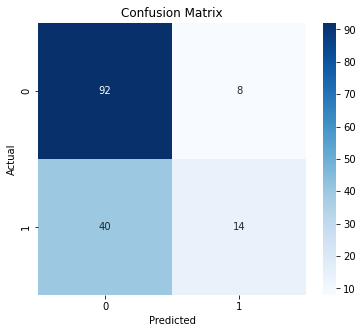

In [35]:
plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Confusion Matrix")

plt.show()

In [38]:
precision = precision_score(y_test, y_pred)

print(precision)

0.6363636363636364


In [39]:
recall = recall_score(y_test, y_pred)

print(recall)

0.25925925925925924


In [40]:
f1 = f1_score(y_test, y_pred)

print(f1)

0.368421052631579


In [41]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.70      0.92      0.79       100
           1       0.64      0.26      0.37        54

    accuracy                           0.69       154
   macro avg       0.67      0.59      0.58       154
weighted avg       0.68      0.69      0.64       154



In [42]:
y_prob = best_model.predict_proba(X_test)[:,1]

In [43]:
fpr, tpr, thresholds = roc_curve(
    y_test,
    y_prob
)

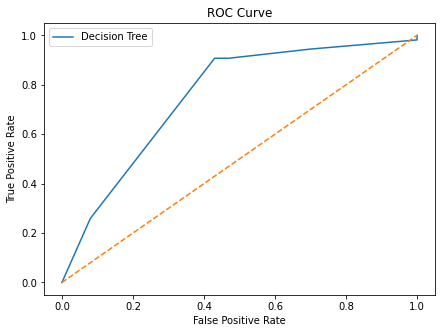

In [44]:
plt.figure(figsize=(7,5))

plt.plot(fpr, tpr, label="Decision Tree")

plt.plot(
    [0,1],
    [0,1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.show()

In [45]:
auc = roc_auc_score(
    y_test,
    y_prob
)

print(auc)

0.7526851851851852


In [47]:
# Get Feature Importance

feature_importance = pd.DataFrame({

    "Feature": X_train.columns,

    "Importance": best_model.feature_importances_

})

feature_importance

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print(feature_importance)

                    Feature  Importance
1                   Glucose    0.695568
5                       BMI    0.269789
4                   Insulin    0.034643
0               Pregnancies    0.000000
2             BloodPressure    0.000000
3             SkinThickness    0.000000
6  DiabetesPedigreeFunction    0.000000
7                       Age    0.000000


Feature Importance measures how much each feature contributes to reducing impurity in the Decision Tree. Features with higher importance have a greater influence on the model's decisions.

Glucose = 0.42

This means Glucose contributed the most toward reducing impurity during tree construction.

It does not mean Glucose alone predicts diabetes.

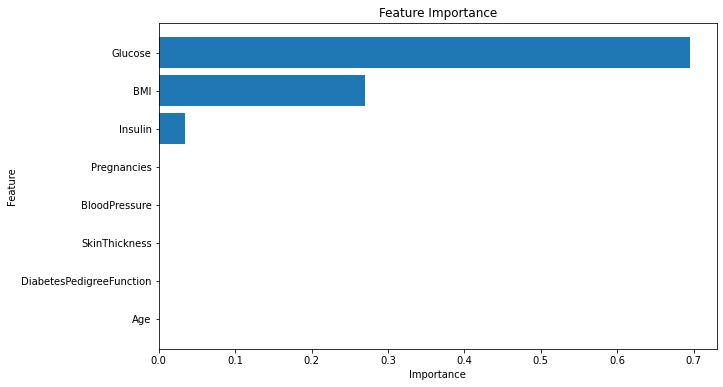

In [48]:
# plot:
plt.figure(figsize=(10,6))

plt.barh(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.xlabel("Importance")

plt.ylabel("Feature")

plt.title("Feature Importance")

plt.gca().invert_yaxis()

plt.show()

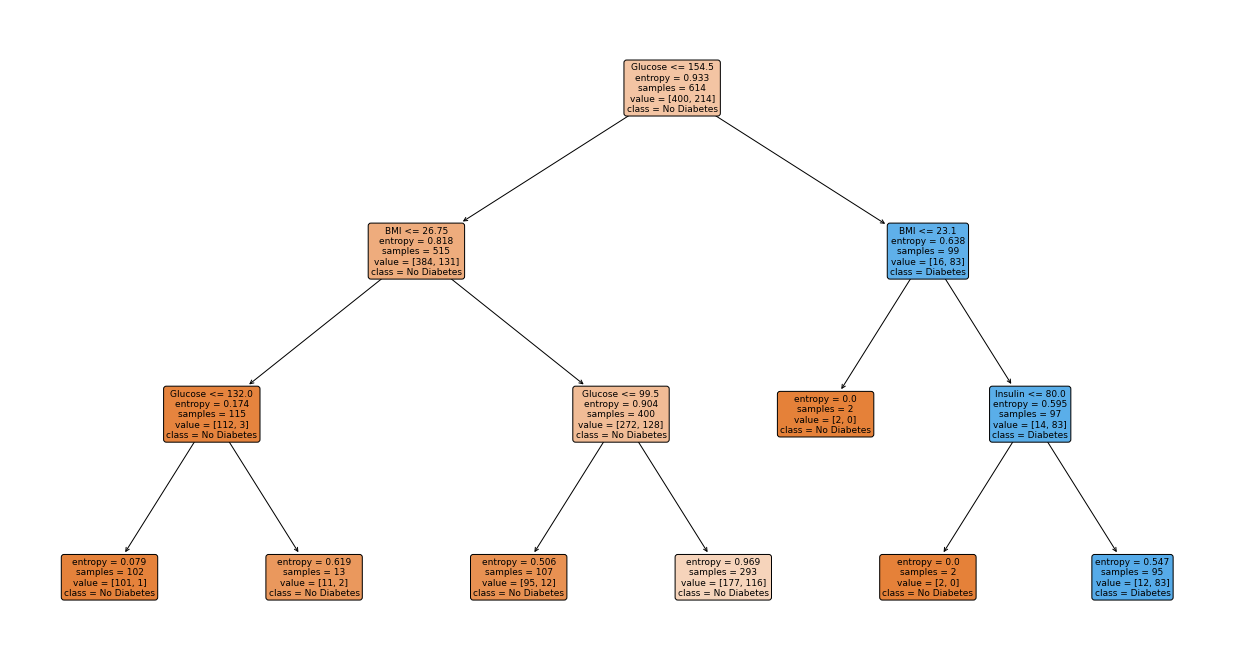

In [49]:
# plot the tree
plt.figure(figsize=(22,12))

plot_tree(

    best_model,

    feature_names=X_train.columns,

    class_names=["No Diabetes","Diabetes"],

    filled=True,

    rounded=True,

    fontsize=9

)

plt.show()

In [50]:
# save the model:
joblib.dump(

    best_model,

    "diabetes_decision_tree.pkl"

)

Why save the model?

Saving the model avoids retraining and allows the same trained model to be reused for future predictions.

Why save the imputer as well?

The model expects new data to be preprocessed exactly like the training data. Saving the imputer ensures consistent preprocessing during inference.

In [ ]:
# after saving load the model:
loaded_model = joblib.load(
    "diabetes_decision_tree.pkl"
)

In [ ]:
# now the trained model is ready to prediction the real world data(unseen data):
new_patient = pd.DataFrame({

    "Pregnancies":[2],

    "Glucose":[160],

    "BloodPressure":[75],

    "SkinThickness":[30],

    "Insulin":[130],

    "BMI":[32.5],

    "DiabetesPedigreeFunction":[0.45],

    "Age":[45]

})

prediction = loaded_model.predict(
    new_patient
)

print(prediction)

In [ ]:
# predict probability:
probability = loaded_model.predict_proba(
    new_patient
)

print(probability)

### Production Pitfalls

A real ML project doesn't end with saving the model.

You also need to save the preprocessing objects.

In [ ]:
# Save:

joblib.dump(best_model, "model.pkl")

joblib.dump(median_imputer, "imputer.pkl")

In [ ]:
joblib.dump(scaler, "scaler.pkl")